# I. Identificación del proyecto
## SUPERVIVENCIA EN EL TITANIC: EXPLORACIÓN DE FACTORES ASOCIADOS A DATOS
### Evaluación Sumativa S01 - Implementación inicial del EDA reproducible

**Asignatura:** MCDI503 - Exploración Inteligente de Datos  
**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Fecha:** 05/09/2026  
**Dataset:** `data/input/Titanic.csv`

### Propósito general
Esta entrega **da continuidad directa a la Evaluación Formativa 1**. La actividad formativa definió el problema, caracterizó `Titanic.csv`, estableció cinco preguntas exploratorias, planificó una secuencia de EDA y fijó criterios iniciales de reproducibilidad. La Sumativa S01 **ejecuta esa planificación de principio a fin** y deja evidencia de cada pregunta mediante la secuencia **pregunta → acción → resultado**.

# II. Contexto y objetivo exploratorio
El proyecto estudia, desde una perspectiva exploratoria, cómo se distribuye la supervivencia de los pasajeros del Titanic y qué patrones iniciales aparecen al compararla con características demográficas y del viaje. La exploración se realiza antes de inferir o modelar y considera, de forma paralela, la calidad del dato.

### Objetivo exploratorio
Describir la supervivencia de los pasajeros y ejecutar las preguntas formuladas en la Formativa 1, evaluando patrones asociados con sexo, clase, edad, tarifa y tamaño del grupo familiar, junto con los problemas de calidad que condicionan la interpretación.

### Preguntas exploratorias heredadas de la Formativa 1
1. ¿Cuál es la proporción de supervivencia y cómo cambia según sexo?
2. ¿Existen diferencias de supervivencia entre las clases de pasajero?
3. ¿Cómo se distribuye `Age` y qué diferencias descriptivas aparecen entre sobrevivientes y no sobrevivientes, considerando sus valores faltantes?
4. ¿Cómo se comporta `Fare` y qué patrones preliminares presenta respecto de **clase y supervivencia**?
5. ¿El tamaño del grupo familiar, derivado de `SibSp` y `Parch`, muestra patrones que convenga profundizar?

### Alcance y supuestos
- EDA descriptivo univariado y bivariado; no se realizan pruebas inferenciales ni modelos predictivos.
- `Survived` se interpreta como binaria (0/1) y `Pclass` como categórica ordinal.
- Nulos y posibles outliers se identifican y documentan antes de cualquier decisión; en esta fase no se imputan ni eliminan automáticamente.
- Las asociaciones observadas son descriptivas y no implican causalidad.

### Organización reproducible del proyecto
Se conserva la misma estructura definida en la Formativa 1:

```text
├── data/
│   ├── input/        # dato original inmutable
│   └── process/      # datos derivados por código
├── figures/          # visualizaciones generadas
├── notebooks/        # notebook ejecutado
├── outputs/          # tablas, resúmenes y trazabilidad
├── Reports/          # informe complementario
├── requirements.txt
└── README.md
```

La secuencia planificada en la Formativa 1 se ejecuta así: **contexto/carga → estructura/tipos → calidad mínima → descriptivos → distribuciones → relaciones simples → `FamilySize` → revisión de outliers → síntesis**.

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def localizar_raiz_proyecto(inicio=None):
    inicio = (inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "data").exists() and (candidato / "notebooks").exists():
            return candidato
    if inicio.name == "notebooks":
        return inicio.parent
    return inicio

BASE_DIR = localizar_raiz_proyecto()
INPUT_DIR = BASE_DIR / "data" / "input"
PROCESS_DIR = BASE_DIR / "data" / "process"
FIGURES_DIR = BASE_DIR / "figures"
OUTPUTS_DIR = BASE_DIR / "outputs"
REPORTS_DIR = BASE_DIR / "Reports"

for d in [INPUT_DIR, PROCESS_DIR, FIGURES_DIR, OUTPUTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {BASE_DIR}")
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__} | numpy: {np.__version__} | matplotlib: {plt.matplotlib.__version__}")

Raíz del proyecto: /mnt/data/MCDI503_S01_FINAL_ALINEADA
Python: 3.13.5
pandas: 2.2.3 | numpy: 2.3.5 | matplotlib: 3.10.8


# III. Carga y revisión inicial de datos
## Acción 1 - Carga controlada e integridad de la fuente
**Decisión:** `Titanic.csv` se conserva sin modificaciones en `data/input/`. El análisis se realiza sobre una copia en memoria y se registra el hash SHA-256 para identificar exactamente la fuente utilizada.

In [2]:
DATA_PATH = INPUT_DIR / "Titanic.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró {DATA_PATH}. Ubique Titanic.csv en data/input/.")

sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw = pd.read_csv(DATA_PATH)
titanic = raw.copy()

print(f"Archivo: {DATA_PATH.relative_to(BASE_DIR).as_posix()}")
print(f"SHA-256: {sha256}")
print(f"Dimensiones: {titanic.shape[0]} filas x {titanic.shape[1]} columnas")
display(titanic.head())

Archivo: data/input/Titanic.csv
SHA-256: 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f
Dimensiones: 891 filas x 12 columnas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


## Acción 2 - Estructura, tipos y calidad mínima
**Motivo:** la planificación formativa indicó revisar dimensiones, variables, tipos, nulos, duplicados, rangos y categorías **antes de interpretar patrones**.

In [3]:
roles = pd.DataFrame({
    "variable": titanic.columns,
    "tipo_python": [str(t) for t in titanic.dtypes],
    "rol_analitico": [
        "identificador", "binaria", "ordinal categórica", "texto/identificación",
        "nominal", "numérica continua", "numérica discreta", "numérica discreta",
        "texto/código", "numérica continua", "texto con alta ausencia", "nominal"
    ]
})
calidad = pd.DataFrame({
    "tipo": titanic.dtypes.astype(str),
    "nulos": titanic.isna().sum(),
    "nulos_pct": (titanic.isna().mean()*100).round(2),
    "unicos": titanic.nunique(dropna=True)
}).sort_values("nulos_pct", ascending=False)

duplicados = int(titanic.duplicated().sum())
print(f"Filas completamente duplicadas: {duplicados}")
display(roles)
display(calidad)

calidad.to_csv(OUTPUTS_DIR / "resumen_calidad.csv", encoding="utf-8")

Filas completamente duplicadas: 0


,variable,tipo_python,rol_analitico
0,PassengerId,int64,identificador
1,Survived,int64,binaria
2,Pclass,int64,ordinal categórica
3,Name,object,texto/identificación
4,Sex,object,nominal
5,Age,float64,numérica continua
6,SibSp,int64,numérica discreta
7,Parch,int64,numérica discreta
8,Ticket,object,texto/código
9,Fare,float64,numérica continua


,tipo,nulos,nulos_pct,unicos
Cabin,object,687,77.100,147
Age,float64,177,19.870,88
Embarked,object,2,0.220,3
PassengerId,int64,0,0.000,891
Name,object,0,0.000,891
Pclass,int64,0,0.000,3
Survived,int64,0,0.000,2
Sex,object,0,0.000,2
Parch,int64,0,0.000,7
SibSp,int64,0,0.000,7


**Resultado e interpretación de la visualización:** `Cabin` concentra aproximadamente **77,1 %** de valores faltantes, `Age` **19,9 %** (177 casos) y `Embarked` **0,2 %**. No existen filas completamente duplicadas. Por continuidad con la Formativa 1, `Cabin` no se incorpora a las preguntas principales y `Age` se analiza solo con casos válidos, sin imputación.

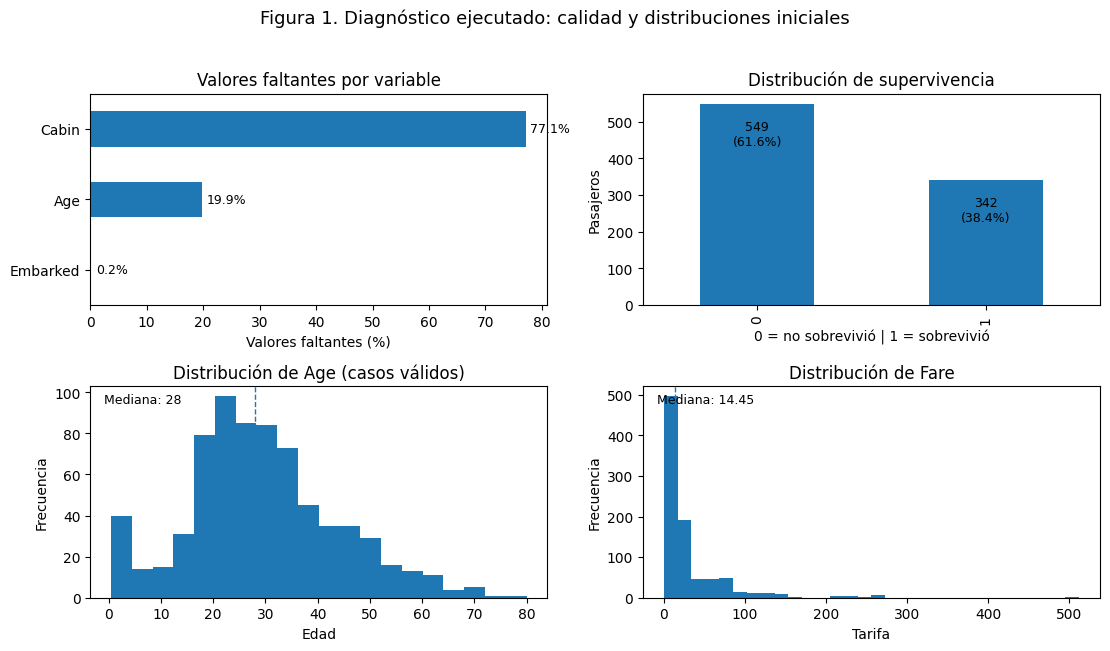

In [4]:
# Figura 1: ejecución del diagnóstico planificado en la Formativa 1
missing = (titanic.isna().mean()*100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0].sort_values()

fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.6))

missing_nonzero.plot(kind="barh", ax=axes[0,0])
axes[0,0].set_title("Valores faltantes por variable")
axes[0,0].set_xlabel("Valores faltantes (%)")
axes[0,0].set_ylabel("")
for i, v in enumerate(missing_nonzero):
    axes[0,0].text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9)

counts = titanic["Survived"].value_counts().sort_index()
counts.plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Distribución de supervivencia")
axes[0,1].set_xlabel("0 = no sobrevivió | 1 = sobrevivió")
axes[0,1].set_ylabel("Pasajeros")
for i, v in enumerate(counts.values):
    axes[0,1].text(i, v - 45, f"{v}\n({v/len(titanic)*100:.1f}%)", ha="center", va="top", fontsize=9)

axes[1,0].hist(titanic["Age"].dropna(), bins=20)
axes[1,0].axvline(titanic["Age"].median(), linestyle="--", linewidth=1)
axes[1,0].set_title("Distribución de Age (casos válidos)")
axes[1,0].set_xlabel("Edad")
axes[1,0].set_ylabel("Frecuencia")
axes[1,0].text(0.03, 0.92, f"Mediana: {titanic['Age'].median():.0f}", transform=axes[1,0].transAxes, fontsize=9)

axes[1,1].hist(titanic["Fare"].dropna(), bins=30)
axes[1,1].axvline(titanic["Fare"].median(), linestyle="--", linewidth=1)
axes[1,1].set_title("Distribución de Fare")
axes[1,1].set_xlabel("Tarifa")
axes[1,1].set_ylabel("Frecuencia")
axes[1,1].text(0.03, 0.92, f"Mediana: {titanic['Fare'].median():.2f}", transform=axes[1,1].transAxes, fontsize=9)

fig.suptitle("Figura 1. Diagnóstico ejecutado: calidad y distribuciones iniciales", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(FIGURES_DIR / "01_diagnostico_calidad_distribuciones.png", dpi=180, bbox_inches="tight")
plt.show()

# IV. Exploración preliminar
A continuación se ejecutan las **cinco preguntas de la Formativa 1**. Cada bloque mantiene la estructura **pregunta → acción → resultado**.

## Pregunta 1 - ¿Cuál es la proporción de supervivencia y cómo cambia según sexo?
**Acción:** calcular la tasa global, las tasas por sexo y contrastarlas visualmente.

In [5]:
surv_global = titanic["Survived"].mean()*100
surv_sex = titanic.groupby("Sex")["Survived"].agg(n="count", sobrevivientes="sum", tasa="mean")
surv_sex["tasa_pct"] = (surv_sex["tasa"]*100).round(1)
print(f"Supervivencia global: {surv_global:.1f}% ({titanic['Survived'].sum()} de {len(titanic)})")
display(surv_sex)
surv_sex.to_csv(OUTPUTS_DIR / "supervivencia_por_sexo.csv", encoding="utf-8")

Supervivencia global: 38.4% (342 de 891)


,n,sobrevivientes,tasa,tasa_pct
Sex,,,,
female,314,233,0.742,74.200
male,577,109,0.189,18.900


**Resultado e interpretación:** sobrevivió el **38,4 %** de los pasajeros. La tasa fue **74,2 % en mujeres** y **18,9 % en hombres**. La diferencia es descriptivamente marcada y justifica mantener `Sex` como variable central, sin interpretar causalidad.

## Pregunta 2 - ¿Existen diferencias de supervivencia entre las clases de pasajero?
**Acción:** comparar la tasa de supervivencia por `Pclass` y revisar el cruce `Sex × Pclass` para evitar una lectura aislada de la clase.

In [6]:
surv_class = titanic.groupby("Pclass")["Survived"].agg(n="count", sobrevivientes="sum", tasa="mean")
surv_class["tasa_pct"] = (surv_class["tasa"]*100).round(1)
sex_class = titanic.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean")*100

display(surv_class)
display(sex_class.round(1))
surv_class.to_csv(OUTPUTS_DIR / "supervivencia_por_clase.csv", encoding="utf-8")
sex_class.round(2).to_csv(OUTPUTS_DIR / "supervivencia_sexo_clase.csv", encoding="utf-8")

,n,sobrevivientes,tasa,tasa_pct
Pclass,,,,
1,216,136,0.630,63.000
2,184,87,0.473,47.300
3,491,119,0.242,24.200


Pclass,1,2,3
Sex,,,
female,96.800,92.100,50.000
male,36.900,15.700,13.500


**Resultado e interpretación:** la supervivencia observada disminuye de **63,0 % en primera clase** a **47,3 % en segunda** y **24,2 % en tercera**. El cruce por sexo muestra que ambos factores presentan patrones simultáneos; por ello se describen conjuntamente y no como efectos causales independientes.

## Pregunta 3 - ¿Cómo se distribuye `Age` y qué diferencias aparecen según supervivencia, considerando sus faltantes?
**Acción:** describir `Age`, contabilizar sus faltantes y comparar la distribución entre sobrevivientes y no sobrevivientes sin imputar datos.

In [7]:
age_stats = titanic.groupby("Survived")["Age"].agg(n="count", media="mean", mediana="median", desv="std")
print(f"Age válidos: {titanic['Age'].notna().sum()} | faltantes: {titanic['Age'].isna().sum()}")
display(age_stats.round(2))
age_stats.round(4).to_csv(OUTPUTS_DIR / "age_por_supervivencia.csv", encoding="utf-8")

Age válidos: 714 | faltantes: 177


,n,media,mediana,desv
Survived,,,,
0,424,30.630,28.000,14.170
1,290,28.340,28.000,14.950


**Resultado e interpretación:** `Age` tiene **714 casos válidos** y **177 faltantes**. La mediana es **28 años** tanto en sobrevivientes como en no sobrevivientes en este primer corte; por sí sola no muestra una separación central evidente. La ausencia de casi una quinta parte de las edades condiciona cualquier interpretación posterior.

## Pregunta 4 - ¿Cómo se comporta `Fare` y qué patrones preliminares presenta respecto de clase y supervivencia?
**Acción:** describir `Fare`, revisar asimetría y valores extremos mediante IQR, y comparar explícitamente la tarifa por **`Pclass` y `Survived`**, tal como quedó planificado en la Formativa 1.

In [8]:
fare_desc = titanic["Fare"].describe()
q1, q3 = titanic["Fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
fare_outliers = titanic["Fare"].notna() & ((titanic["Fare"] < low) | (titanic["Fare"] > high))

fare_surv = titanic.groupby("Survived")["Fare"].agg(n="count", media="mean", mediana="median")
fare_class = titanic.groupby("Pclass")["Fare"].agg(n="count", media="mean", mediana="median")
fare_class_surv = titanic.groupby(["Pclass","Survived"])["Fare"].agg(n="count", media="mean", mediana="median")

print(f"Fare mediana: {titanic['Fare'].median():.2f} | máximo: {titanic['Fare'].max():.2f}")
print(f"Límites IQR: [{low:.2f}, {high:.2f}] | observaciones fuera de límites: {fare_outliers.sum()}")
display(fare_surv.round(2))
display(fare_class.round(2))
display(fare_class_surv.round(2))

fare_surv.round(4).to_csv(OUTPUTS_DIR / "fare_por_supervivencia.csv", encoding="utf-8")
fare_class.round(4).to_csv(OUTPUTS_DIR / "fare_por_clase.csv", encoding="utf-8")
fare_class_surv.round(4).to_csv(OUTPUTS_DIR / "fare_por_clase_y_supervivencia.csv", encoding="utf-8")
pd.DataFrame({"limite_inferior":[low],"limite_superior":[high],"casos_fuera_iqr":[int(fare_outliers.sum())]}).to_csv(OUTPUTS_DIR / "revision_outliers_fare_iqr.csv", index=False)

Fare mediana: 14.45 | máximo: 512.33
Límites IQR: [-26.72, 65.63] | observaciones fuera de límites: 116


,n,media,mediana
Survived,,,
0,549,22.120,10.500
1,342,48.400,26.000


,n,media,mediana
Pclass,,,
1,216,84.150,60.290
2,184,20.660,14.250
3,491,13.680,8.050


n  media  mediana
Pclass Survived                     
1      0          80 64.680   44.750
       1         136 95.610   77.960
2      0          97 19.410   13.000
       1          87 22.060   21.000
3      0         372 13.670    8.050
       1         119 13.690    8.520

**Resultado e interpretación:** `Fare` es fuertemente asimétrica a la derecha (mediana **14,45**, máximo **512,33**) y la regla IQR identifica **116** observaciones altas. Se conservan porque no existe evidencia de que sean errores. La mediana de tarifa es **26,0** entre sobrevivientes frente a **10,5** entre no sobrevivientes; además cambia de forma sustantiva por clase (**60,29** en 1.ª, **14,25** en 2.ª y **8,05** en 3.ª). El cruce `Pclass × Survived` muestra que la diferencia de `Fare` debe interpretarse junto con la clase y no como una asociación aislada.

# V. Decisiones y transformaciones iniciales
## Pregunta 5 - ¿El tamaño del grupo familiar, derivado de `SibSp` y `Parch`, muestra patrones que convenga profundizar?

**Decisión D4 heredada de la planificación:** implementar `FamilySize = SibSp + Parch + 1` mediante código. Como extensión secundaria surgida durante la ejecución, se deriva `IsAlone` únicamente para resumir el contraste entre viajar solo y acompañado; **no reemplaza la pregunta original sobre `FamilySize`**.

In [9]:
titanic["FamilySize"] = titanic["SibSp"] + titanic["Parch"] + 1
# Extensión secundaria para síntesis; la variable planificada principal sigue siendo FamilySize.
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

family = titanic.groupby("FamilySize")["Survived"].agg(n="count", tasa="mean")
family["tasa_pct"] = (family["tasa"]*100).round(1)
alone = titanic.groupby("IsAlone")["Survived"].agg(n="count", tasa="mean")
alone["tasa_pct"] = (alone["tasa"]*100).round(1)

display(family)
display(alone.rename(index={0:"Con familiares",1:"Solo"}))
family.to_csv(OUTPUTS_DIR / "supervivencia_por_tamano_familiar.csv", encoding="utf-8")
alone.to_csv(OUTPUTS_DIR / "supervivencia_solo_vs_acompanado.csv", encoding="utf-8")

processed_path = PROCESS_DIR / "titanic_eda_process.csv"
titanic.to_csv(processed_path, index=False, encoding="utf-8")
print(f"Datos procesados exportados: {processed_path.relative_to(BASE_DIR).as_posix()}")

,n,tasa,tasa_pct
FamilySize,,,
1,537,0.304,30.400
2,161,0.553,55.300
3,102,0.578,57.800
4,29,0.724,72.400
5,15,0.200,20.000
6,22,0.136,13.600
7,12,0.333,33.300
8,6,0.000,0.000
11,7,0.000,0.000


,n,tasa,tasa_pct
IsAlone,,,
Con familiares,354,0.506,50.600
Solo,537,0.304,30.400


Datos procesados exportados: data/process/titanic_eda_process.csv


**Resultado e interpretación:** `FamilySize` muestra un patrón **no lineal**. Los grupos de 2 a 4 personas registran tasas superiores a quienes viajan solos, mientras los grupos grandes tienen pocos casos y tasas menores. Viajar solo resume una tasa de **30,4 %**, frente a **50,6 %** entre quienes registran al menos un familiar. Los tamaños de grupo deben interpretarse considerando su frecuencia (`n`).

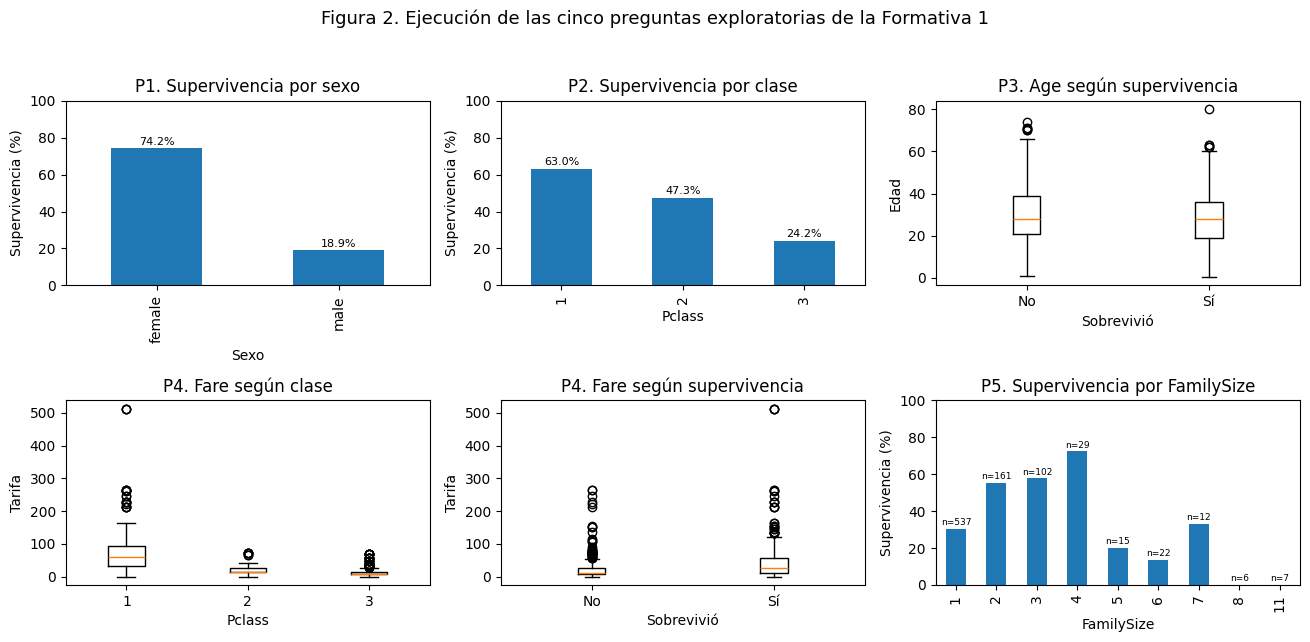

In [10]:
# Figura 2: síntesis gráfica de las cinco preguntas de la Formativa 1
fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.5))

surv_sex["tasa_pct"].plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("P1. Supervivencia por sexo")
axes[0,0].set_ylabel("Supervivencia (%)")
axes[0,0].set_xlabel("Sexo")
axes[0,0].set_ylim(0, 100)
for i,v in enumerate(surv_sex["tasa_pct"].values):
    axes[0,0].text(i, v+2, f"{v:.1f}%", ha="center", fontsize=8)

surv_class["tasa_pct"].plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("P2. Supervivencia por clase")
axes[0,1].set_ylabel("Supervivencia (%)")
axes[0,1].set_xlabel("Pclass")
axes[0,1].set_ylim(0, 100)
for i,v in enumerate(surv_class["tasa_pct"].values):
    axes[0,1].text(i, v+2, f"{v:.1f}%", ha="center", fontsize=8)

age_groups = [titanic.loc[titanic['Survived']==0,'Age'].dropna(), titanic.loc[titanic['Survived']==1,'Age'].dropna()]
axes[0,2].boxplot(age_groups, tick_labels=["No", "Sí"])
axes[0,2].set_title("P3. Age según supervivencia")
axes[0,2].set_ylabel("Edad")
axes[0,2].set_xlabel("Sobrevivió")

fare_by_class = [titanic.loc[titanic['Pclass']==cl,'Fare'].dropna() for cl in [1,2,3]]
axes[1,0].boxplot(fare_by_class, tick_labels=["1", "2", "3"], showfliers=True)
axes[1,0].set_title("P4. Fare según clase")
axes[1,0].set_ylabel("Tarifa")
axes[1,0].set_xlabel("Pclass")

fare_by_surv = [titanic.loc[titanic['Survived']==0,'Fare'].dropna(), titanic.loc[titanic['Survived']==1,'Fare'].dropna()]
axes[1,1].boxplot(fare_by_surv, tick_labels=["No", "Sí"], showfliers=True)
axes[1,1].set_title("P4. Fare según supervivencia")
axes[1,1].set_ylabel("Tarifa")
axes[1,1].set_xlabel("Sobrevivió")

family["tasa_pct"].plot(kind="bar", ax=axes[1,2])
axes[1,2].set_title("P5. Supervivencia por FamilySize")
axes[1,2].set_ylabel("Supervivencia (%)")
axes[1,2].set_xlabel("FamilySize")
axes[1,2].set_ylim(0, 100)
for i, (_,row) in enumerate(family.iterrows()):
    axes[1,2].text(i, row['tasa_pct']+2, f"n={int(row['n'])}", ha="center", fontsize=6.5)

fig.suptitle("Figura 2. Ejecución de las cinco preguntas exploratorias de la Formativa 1", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(FIGURES_DIR / "02_relaciones_preguntas_ejecutadas.png", dpi=180, bbox_inches="tight")
plt.show()

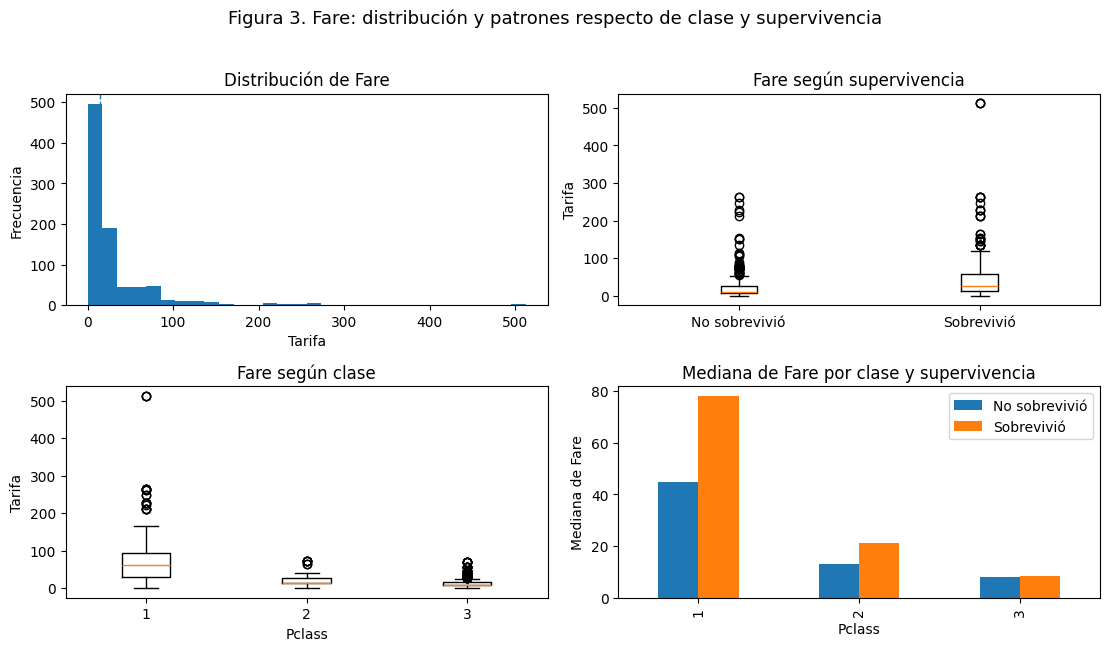

In [11]:
# Figura 3: ejecución completa de la pregunta 4 - Fare respecto de clase y supervivencia
fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.6))

axes[0,0].hist(titanic["Fare"].dropna(), bins=30)
axes[0,0].axvline(titanic["Fare"].median(), linestyle="--", linewidth=1)
axes[0,0].set_title("Distribución de Fare")
axes[0,0].set_xlabel("Tarifa")
axes[0,0].set_ylabel("Frecuencia")

fare_by_surv = [titanic.loc[titanic['Survived']==0,'Fare'].dropna(), titanic.loc[titanic['Survived']==1,'Fare'].dropna()]
axes[0,1].boxplot(fare_by_surv, tick_labels=["No sobrevivió", "Sobrevivió"], showfliers=True)
axes[0,1].set_title("Fare según supervivencia")
axes[0,1].set_ylabel("Tarifa")

fare_by_class = [titanic.loc[titanic['Pclass']==c,'Fare'].dropna() for c in [1,2,3]]
axes[1,0].boxplot(fare_by_class, tick_labels=["1", "2", "3"], showfliers=True)
axes[1,0].set_title("Fare según clase")
axes[1,0].set_xlabel("Pclass")
axes[1,0].set_ylabel("Tarifa")

pivot_median = titanic.pivot_table(index="Pclass", columns="Survived", values="Fare", aggfunc="median")
pivot_median.columns = ["No sobrevivió", "Sobrevivió"]
pivot_median.plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Mediana de Fare por clase y supervivencia")
axes[1,1].set_xlabel("Pclass")
axes[1,1].set_ylabel("Mediana de Fare")
axes[1,1].legend(title="")

fig.suptitle("Figura 3. Fare: distribución y patrones respecto de clase y supervivencia", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(FIGURES_DIR / "03_fare_clase_supervivencia.png", dpi=180, bbox_inches="tight")
plt.show()

## Registro trazable de decisiones exploratorias
| ID | Decisión | Motivo | Resultado intermedio |
|---|---|---|---|
| D1 | Mantener `Titanic.csv` inmutable | Preservar la fuente original | Transformaciones solo sobre copia y exportación a `data/process/` |
| D2 | No imputar nulos en S01 | Evitar introducir supuestos prematuros | `Age` usa casos válidos; `Cabin` queda fuera del foco inicial |
| D3 | Tratar `Pclass` como ordinal categórica | 1-3 representan clases, no una magnitud continua | Comparaciones por categoría |
| D4 | Crear `FamilySize` | Ejecutar la transformación planificada en la Formativa 1 | Variable derivada reproducible |
| D5 | Crear `IsAlone` como extensión secundaria | Resumir viajar solo vs. acompañado sin reemplazar `FamilySize` | Indicador adicional documentado |
| D6 | Conservar extremos de `Fare` | IQR identifica casos altos, pero no prueba error | 116 observaciones marcadas, ninguna eliminada |

# VI. Resultados e interpretación inicial
La siguiente matriz resume la correspondencia requerida entre las cinco preguntas formuladas en la Formativa 1, la acción ejecutada y el resultado obtenido.

In [12]:
resultados = pd.DataFrame([
    ["P1", "Tasa global y por Sex", "38,4 % global; 74,2 % mujeres; 18,9 % hombres", "Figura 2"],
    ["P2", "Tasas por Pclass y cruce Sex × Pclass", "63,0 % clase 1; 47,3 % clase 2; 24,2 % clase 3", "Figura 2"],
    ["P3", "Descriptivos y boxplot de Age", "177 nulos; mediana 28 en ambos grupos", "Figuras 1-2"],
    ["P4", "Fare: IQR, supervivencia, Pclass y cruce", "Medianas por clase 60,29 / 14,25 / 8,05; 26,0 vs 10,5 por supervivencia", "Figuras 1 y 3"],
    ["P5", "FamilySize y tasas con n por grupo", "Patrón no lineal; solo 30,4 % vs acompañado 50,6 %", "Figura 2"],
], columns=["Pregunta","Acción ejecutada","Resultado inicial","Evidencia"])
display(resultados)
resultados.to_csv(OUTPUTS_DIR / "tabla_pregunta_accion_resultado.csv", index=False, encoding="utf-8")

,Pregunta,Acción ejecutada,Resultado inicial,Evidencia
0,P1,Tasa global y por Sex,"38,4 % global; 74,2 % mujeres; 18,9 % hombres",Figura 2
1,P2,Tasas por Pclass y cruce Sex × Pclass,"63,0 % clase 1; 47,3 % clase 2; 24,2 % clase 3",Figura 2
2,P3,Descriptivos y boxplot de Age,177 nulos; mediana 28 en ambos grupos,Figuras 1-2
3,P4,"Fare: IQR, supervivencia, Pclass y cruce","Medianas por clase 60,29 / 14,25 / 8,05; 26,0 ...",Figuras 1 y 3
4,P5,FamilySize y tasas con n por grupo,"Patrón no lineal; solo 30,4 % vs acompañado 50...",Figura 2


### Síntesis de hallazgos
1. **Sexo y clase** presentan las diferencias descriptivas de supervivencia más marcadas y deben leerse conjuntamente.
2. **Age** no muestra diferencia de mediana entre grupos en este primer corte; sus 177 faltantes limitan la interpretación.
3. **Fare** es asimétrica y sus valores altos no se eliminan automáticamente. Su nivel cambia claramente por `Pclass`, por lo que la mayor tarifa observada entre sobrevivientes debe interpretarse junto con la clase.
4. **FamilySize** muestra un patrón no lineal: los tamaños intermedios presentan tasas más altas, mientras grupos grandes tienen pocos casos y requieren cautela.
5. La calidad no es homogénea: `Cabin` tiene 77,1 % de ausencia y queda fuera del foco de esta primera implementación.

# VII. Supuestos y limitaciones
### Supuestos
- Cada fila representa un pasajero y `PassengerId` identifica registros individuales.
- `Survived` y `Pclass` están correctamente codificados según el archivo proporcionado.
- `FamilySize = SibSp + Parch + 1` aproxima el tamaño del grupo familiar registrado dentro del dataset.

### Limitaciones
- `Cabin` presenta 77,1 % de ausencia; no se utiliza en las preguntas de esta fase.
- `Age` tiene 177 valores faltantes; no se imputan y sus resultados usan únicamente casos disponibles.
- `Fare` presenta fuerte asimetría y valores extremos; se emplean medianas y se documentan los casos IQR sin eliminarlos.
- El conjunto es histórico y observacional; los patrones no permiten establecer causalidad ni generalizar sin análisis adicional.
- Esta fase se limita a EDA descriptivo; inferencia y modelamiento quedan para etapas posteriores.

# VIII. Cierre del avance
La Sumativa S01 **consolida la planificación de la Formativa 1**: mantiene el mismo problema, dataset, cinco preguntas, secuencia de análisis, variable derivada principal (`FamilySize`) y criterios de reproducibilidad. La diferencia es que ahora cada elemento está **ejecutado, cuantificado, visualizado y documentado**.

La evidencia queda trazable mediante:
- `data/input/Titanic.csv`: fuente original inmutable;
- `data/process/titanic_eda_process.csv`: datos derivados por código;
- `figures/01_...`, `02_...`, `03_...`: figuras generadas por la ejecución;
- `outputs/*.csv`: resultados intermedios y matriz pregunta→acción→resultado;
- `outputs/manifest_ejecucion.txt`: hash de entrada y versiones del entorno.

La continuidad esperada para las siguientes fases es profundizar las asociaciones detectadas, evaluar tratamientos de faltantes con justificación metodológica y avanzar hacia análisis inferencial o modelamiento únicamente cuando corresponda al alcance del curso.

In [13]:
manifest = "\n".join([
    f"archivo_entrada={DATA_PATH.relative_to(BASE_DIR).as_posix()}",
    f"sha256={sha256}",
    f"filas_entrada={raw.shape[0]}",
    f"columnas_entrada={raw.shape[1]}",
    f"archivo_procesado={(PROCESS_DIR/'titanic_eda_process.csv').relative_to(BASE_DIR).as_posix()}",
    f"columnas_procesadas={titanic.shape[1]}",
    f"python={sys.version.split()[0]}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"matplotlib={plt.matplotlib.__version__}",
])
(OUTPUTS_DIR / "manifest_ejecucion.txt").write_text(manifest, encoding="utf-8")

resumen = f"""# Resumen EDA - Sumativa S01\n\n- Supervivencia global: {surv_global:.1f}%\n- Mujeres: {surv_sex.loc['female','tasa_pct']:.1f}%\n- Hombres: {surv_sex.loc['male','tasa_pct']:.1f}%\n- Pclass 1/2/3: {surv_class.loc[1,'tasa_pct']:.1f}% / {surv_class.loc[2,'tasa_pct']:.1f}% / {surv_class.loc[3,'tasa_pct']:.1f}%\n- Age faltantes: {titanic['Age'].isna().sum()}\n- Fare mediana por Pclass: {fare_class.loc[1,'mediana']:.2f} / {fare_class.loc[2,'mediana']:.2f} / {fare_class.loc[3,'mediana']:.2f}\n- Fare fuera de límites IQR: {int(fare_outliers.sum())}\n- FamilySize: patrón no lineal, interpretar con n por grupo.\n"""
(OUTPUTS_DIR / "resumen_eda.md").write_text(resumen, encoding="utf-8")
print(manifest)

archivo_entrada=data/input/Titanic.csv
sha256=7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f
filas_entrada=891
columnas_entrada=12
archivo_procesado=data/process/titanic_eda_process.csv
columnas_procesadas=14
python=3.13.5
pandas=2.2.3
numpy=2.3.5
matplotlib=3.10.8
